
# 1D CNN 高光谱分类教学 Notebook

这个 Notebook 以 `Indian Pines` 数据集为例，演示如何使用 **1D CNN** 完成高光谱像素分类。

这份教学 Notebook 的目标有两个：

1. 让初学者理解高光谱像素分类里，为什么 1D CNN 是一个合理的入门深度学习 baseline。
2. 给仓库提供一个**可执行、可复现、带输出结果**的深度学习教学样例。

和 `HybridSN` 相比，1D CNN 更轻量，重点放在**光谱维度建模**，适合做从传统机器学习过渡到深度学习的第一站。



## 本 Notebook 会完成什么

我们会按下面的顺序推进：

1. 读取 `Indian Pines` 数据与标签。
2. 观察数据形状、类别数量与样本分布。
3. 把高光谱立方体展开成像素级样本。
4. 进行训练集、验证集、测试集划分。
5. 构建一个简单的 1D CNN。
6. 训练模型并观察 loss / accuracy 曲线。
7. 在测试集上评估 OA、AA、Kappa 和分类报告。
8. 生成整图预测结果并可视化。

> 说明：这里采用的是**像素级分类**思路。每个像素的光谱向量被看作一个长度为 `波段数` 的一维序列，交给 1D 卷积网络处理。


In [1]:

import json
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from scipy.io import loadmat
from sklearn.metrics import accuracy_score, classification_report, cohen_kappa_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

plt.style.use('default')
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.unicode_minus'] = False

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device =', device)


device = cuda



## 1. 读取数据

`Indian Pines` 是高光谱分类里非常经典的数据集。

- 数据立方体形状通常是 `(height, width, bands)`
- 标签图形状通常是 `(height, width)`
- 标签值 `0` 表示背景，不参与监督训练
- 非零标签表示真实地物类别


In [2]:

dataset_dir = Path('dataset')
cube = loadmat(dataset_dir / 'Indian_pines_corrected.mat')['indian_pines_corrected']
gt = loadmat(dataset_dir / 'Indian_pines_gt.mat')['indian_pines_gt']

class_names = [
    'Alfalfa', 'Corn-notill', 'Corn-mintill', 'Corn', 'Grass-pasture',
    'Grass-trees', 'Grass-pasture-mowed', 'Hay-windrowed', 'Oats',
    'Soybean-notill', 'Soybean-mintill', 'Soybean-clean', 'Wheat',
    'Woods', 'Buildings-Grass-Trees-Drives', 'Stone-Steel-Towers'
]

print('cube shape:', cube.shape)
print('gt shape:', gt.shape)
print('dtype:', cube.dtype, gt.dtype)
print('num classes:', len(class_names))
print('labeled pixels:', int((gt != 0).sum()))


cube shape: (145, 145, 200)
gt shape: (145, 145)
dtype: uint16 uint8
num classes: 16
labeled pixels: 10249


In [3]:

unique, counts = np.unique(gt, return_counts=True)
class_count_df = pd.DataFrame({'label': unique, 'count': counts})
class_count_df = class_count_df[class_count_df['label'] != 0].copy()
class_count_df['class_name'] = class_count_df['label'].apply(lambda x: class_names[x - 1])
class_count_df = class_count_df[['label', 'class_name', 'count']].sort_values('label')
class_count_df


,label,class_name,count
1,1,Alfalfa,46
2,2,Corn-notill,1428
3,3,Corn-mintill,830
4,4,Corn,237
5,5,Grass-pasture,483
6,6,Grass-trees,730
7,7,Grass-pasture-mowed,28
8,8,Hay-windrowed,478
9,9,Oats,20
10,10,Soybean-notill,972


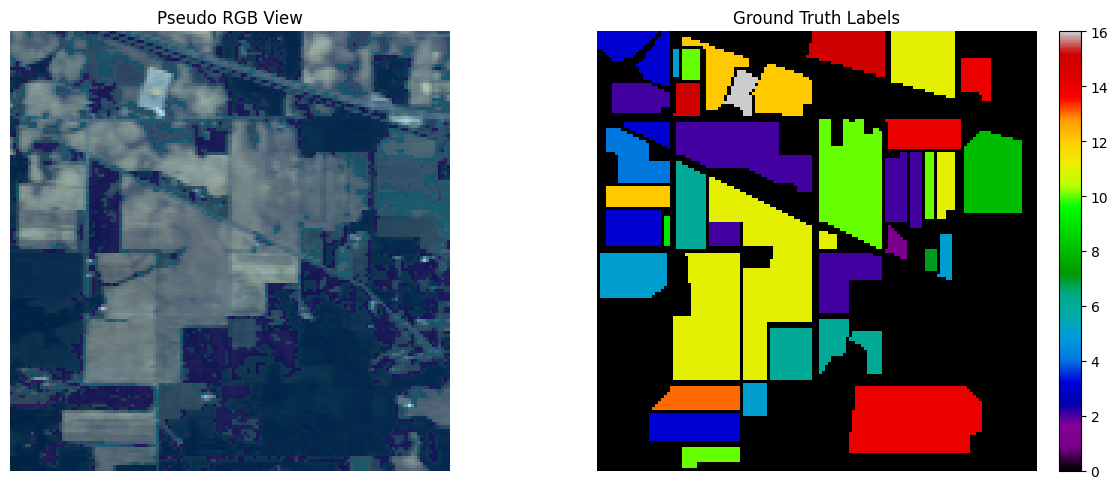

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

rgb = cube[:, :, [29, 19, 9]].astype(np.float32)
rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)
axes[0].imshow(rgb)
axes[0].set_title('Pseudo RGB View')
axes[0].axis('off')

im = axes[1].imshow(gt, cmap='nipy_spectral', vmin=0, vmax=len(class_names))
axes[1].set_title('Ground Truth Labels')
axes[1].axis('off')
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()



## 2. 构造像素级样本

1D CNN 的输入不是二维 patch，而是**每个像素的光谱向量**。

也就是说：

- 输入特征 `X` 的形状会是 `(样本数, 波段数)`
- 标签 `y` 的形状会是 `(样本数,)`

这里只保留标签不为 0 的像素。


In [5]:

mask = gt != 0
X = cube[mask].astype(np.float32)
y = gt[mask].astype(np.int64) - 1
positions = np.argwhere(mask)

print('X shape:', X.shape)
print('y shape:', y.shape)
print('positions shape:', positions.shape)
print('bands per pixel:', X.shape[1])


X shape: (10249, 200)
y shape: (10249,)
positions shape: (10249, 2)
bands per pixel: 200



## 3. 划分训练 / 验证 / 测试集

这里采用两步划分：

1. 先划出训练集。
2. 再把剩余样本划分成验证集和测试集。

这样做的好处是比较清晰，也便于后续和仓库里的其他基线保持一致。


In [6]:

TRAIN_RATIO = 0.1
VAL_RATIO = 0.1
TEST_RATIO = 0.8

X_train, X_temp, y_train, y_temp, pos_train, pos_temp = train_test_split(
    X, y, positions,
    train_size=TRAIN_RATIO,
    stratify=y,
    random_state=SEED,
)

val_ratio_within_temp = VAL_RATIO / (VAL_RATIO + TEST_RATIO)
X_val, X_test, y_val, y_test, pos_val, pos_test = train_test_split(
    X_temp, y_temp, pos_temp,
    train_size=val_ratio_within_temp,
    stratify=y_temp,
    random_state=SEED,
)

print('train:', X_train.shape, y_train.shape)
print('val:  ', X_val.shape, y_val.shape)
print('test: ', X_test.shape, y_test.shape)


train: (1024, 200) (1024,)
val:   (1025, 200) (1025,)
test:  (8200, 200) (8200,)


In [7]:

def count_by_class(labels, class_names):
    values, counts = np.unique(labels, return_counts=True)
    rows = []
    for v, c in zip(values, counts):
        rows.append({'label': int(v + 1), 'class_name': class_names[v], 'count': int(c)})
    return pd.DataFrame(rows)

split_summary = pd.concat([
    count_by_class(y_train, class_names).assign(split='train'),
    count_by_class(y_val, class_names).assign(split='val'),
    count_by_class(y_test, class_names).assign(split='test'),
], ignore_index=True)

split_summary.head(12)


,label,class_name,count,split
0,1,Alfalfa,5,train
1,2,Corn-notill,143,train
2,3,Corn-mintill,83,train
3,4,Corn,24,train
4,5,Grass-pasture,48,train
5,6,Grass-trees,73,train
6,7,Grass-pasture-mowed,3,train
7,8,Hay-windrowed,48,train
8,9,Oats,2,train
9,10,Soybean-notill,97,train



## 4. 特征标准化

高光谱各波段的数值范围可能不同。对于 1D CNN 这类直接吃光谱向量的模型，先做标准化通常更稳。

这里采用：

- 只在训练集上 `fit`
- 再把同一个变换应用到验证集和测试集

这样可以避免数据泄漏。


In [8]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)
X_val_scaled = scaler.transform(X_val).astype(np.float32)
X_test_scaled = scaler.transform(X_test).astype(np.float32)
X_all_scaled = scaler.transform(X).astype(np.float32)

print(X_train_scaled.mean(), X_train_scaled.std())
print(X_val_scaled.shape, X_test_scaled.shape)


-1.7881393e-09 0.99999994
(1025, 200) (8200, 200)



## 5. 构建 PyTorch 数据集

对于 `Conv1d`，输入通常写成：

- `(batch, channels, length)`

而我们的光谱向量本来是 `(batch, bands)`，所以这里把它变形成：

- `(batch, 1, bands)`


In [9]:

def to_tensor_dataset(features, labels):
    x_tensor = torch.from_numpy(features).unsqueeze(1)
    y_tensor = torch.from_numpy(labels)
    return TensorDataset(x_tensor, y_tensor)

BATCH_SIZE = 256

train_ds = to_tensor_dataset(X_train_scaled, y_train)
val_ds = to_tensor_dataset(X_val_scaled, y_val)
test_ds = to_tensor_dataset(X_test_scaled, y_test)
all_ds = TensorDataset(torch.from_numpy(X_all_scaled).unsqueeze(1), torch.from_numpy(y))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)
all_loader = DataLoader(all_ds, batch_size=BATCH_SIZE, shuffle=False)

next(iter(train_loader))[0].shape


torch.Size([256, 1, 200])


## 6. 定义 1D CNN

这个模型的设计思路很直接：

1. 用 `Conv1d` 在光谱维度上提取局部模式。
2. 用池化逐步压缩光谱长度。
3. 最后接全连接层输出类别概率。

这不是追求 SOTA 的结构，而是一个适合教学和复现的轻量 baseline。


In [10]:

class SpectralCNN1D(nn.Module):
    def __init__(self, num_bands, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=7, padding=3),
            nn.BatchNorm1d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2),

            nn.Conv1d(16, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2),

            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool1d(8),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = SpectralCNN1D(num_bands=X_train_scaled.shape[1], num_classes=len(class_names)).to(device)
model


SpectralCNN1D(
  (features): Sequential(
    (0): Conv1d(1, 16, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(16, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): AdaptiveAvgPool1d(output_size=8)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=512, out_features=128, bias=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.3, in

In [11]:

@torch.no_grad()
def evaluate_model(model, data_loader, device):
    model.eval()
    all_preds = []
    all_targets = []
    total_correct = 0
    total_count = 0
    for xb, yb in data_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        logits = model(xb)
        preds = logits.argmax(dim=1)
        total_correct += (preds == yb).sum().item()
        total_count += yb.size(0)
        all_preds.append(preds.cpu().numpy())
        all_targets.append(yb.cpu().numpy())
    acc = total_correct / total_count
    y_true = np.concatenate(all_targets)
    y_pred = np.concatenate(all_preds)
    return acc, y_true, y_pred

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
EPOCHS = 15

history = {
    'train_loss': [],
    'train_acc': [],
    'val_acc': [],
}



## 7. 训练模型

这里每个 epoch 都会记录：

- 训练损失 `train_loss`
- 训练准确率 `train_acc`
- 验证准确率 `val_acc`

同时保留验证集上表现最好的模型权重。


In [12]:

best_state = None
best_val_acc = -1.0

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * yb.size(0)
        running_correct += (logits.argmax(dim=1) == yb).sum().item()
        running_total += yb.size(0)

    train_loss = running_loss / running_total
    train_acc = running_correct / running_total
    val_acc, _, _ = evaluate_model(model, val_loader, device)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    if val_acc >= best_val_acc:
        best_val_acc = val_acc
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    print(f'Epoch {epoch:02d}/{EPOCHS} | loss={train_loss:.4f} | train_acc={train_acc:.4f} | val_acc={val_acc:.4f}')

print('best_val_acc =', round(best_val_acc, 4))


Epoch 01/15 | loss=2.4462 | train_acc=0.3105 | val_acc=0.3620
Epoch 02/15 | loss=1.9641 | train_acc=0.3730 | val_acc=0.3873


Epoch 03/15 | loss=1.7186 | train_acc=0.4316 | val_acc=0.4410
Epoch 04/15 | loss=1.5927 | train_acc=0.4717 | val_acc=0.4751


Epoch 05/15 | loss=1.4875 | train_acc=0.4961 | val_acc=0.4800
Epoch 06/15 | loss=1.4316 | train_acc=0.5098 | val_acc=0.5034


Epoch 07/15 | loss=1.3343 | train_acc=0.5137 | val_acc=0.5220
Epoch 08/15 | loss=1.2944 | train_acc=0.5332 | val_acc=0.5229


Epoch 09/15 | loss=1.2627 | train_acc=0.5420 | val_acc=0.5571
Epoch 10/15 | loss=1.2268 | train_acc=0.5664 | val_acc=0.5561


Epoch 11/15 | loss=1.1983 | train_acc=0.5479 | val_acc=0.5522
Epoch 12/15 | loss=1.1473 | train_acc=0.5752 | val_acc=0.5873


Epoch 13/15 | loss=1.1258 | train_acc=0.5840 | val_acc=0.5990
Epoch 14/15 | loss=1.1042 | train_acc=0.6084 | val_acc=0.6098


Epoch 15/15 | loss=1.0870 | train_acc=0.5938 | val_acc=0.6137
best_val_acc = 0.6137


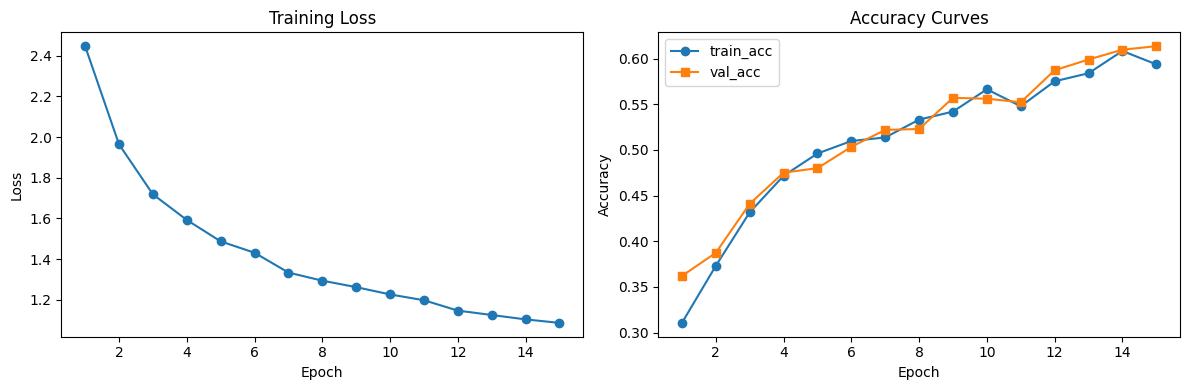

In [13]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

epoch_index = np.arange(1, EPOCHS + 1)
axes[0].plot(epoch_index, history['train_loss'], marker='o')
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')

axes[1].plot(epoch_index, history['train_acc'], marker='o', label='train_acc')
axes[1].plot(epoch_index, history['val_acc'], marker='s', label='val_acc')
axes[1].set_title('Accuracy Curves')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()



## 8. 在测试集上评估

这里计算四类常见指标：

- `OA`：Overall Accuracy，总体准确率
- `AA`：Average Accuracy，各类别召回率的平均
- `Kappa`：考虑随机一致性的指标
- `classification_report`：每类 precision / recall / f1-score


In [14]:

model.load_state_dict(best_state)
model.to(device)

test_acc, y_true_test, y_pred_test = evaluate_model(model, test_loader, device)
oa = accuracy_score(y_true_test, y_pred_test)
aa = recall_score(y_true_test, y_pred_test, average='macro', zero_division=0)
kappa = cohen_kappa_score(y_true_test, y_pred_test)

print('Test accuracy:', round(test_acc, 4))
print('OA:', round(oa, 4))
print('AA:', round(aa, 4))
print('Kappa:', round(kappa, 4))


Test accuracy: 0.6149
OA: 0.6149
AA: 0.4543
Kappa: 0.5455


In [15]:

report = classification_report(
    y_true_test,
    y_pred_test,
    target_names=class_names,
    digits=4,
    zero_division=0,
)
print(report)


                              precision    recall  f1-score   support

                     Alfalfa     0.0000    0.0000    0.0000        37
                 Corn-notill     0.5969    0.4422    0.5080      1142
                Corn-mintill     0.6136    0.3946    0.4803       664
                        Corn     0.9412    0.0847    0.1553       189
               Grass-pasture     0.7564    0.3049    0.4346       387
                 Grass-trees     0.6756    0.9058    0.7740       584
         Grass-pasture-mowed     0.0000    0.0000    0.0000        22
               Hay-windrowed     0.7900    0.9948    0.8806       382
                        Oats     0.0000    0.0000    0.0000        16
              Soybean-notill     0.5111    0.2069    0.2946       778
             Soybean-mintill     0.5193    0.8830    0.6540      1965
               Soybean-clean     0.5160    0.2379    0.3256       475
                       Wheat     0.8142    0.9085    0.8588       164
                   


## 9. 整图预测与可视化

虽然 1D CNN 是像素级分类模型，但我们依然可以对整张图的每个有标签像素做预测，再把结果还原成二维分类图。


In [16]:

@torch.no_grad()
def predict_all(model, features, batch_size=512):
    model.eval()
    preds = []
    tensor_x = torch.from_numpy(features).unsqueeze(1)
    loader = DataLoader(tensor_x, batch_size=batch_size, shuffle=False)
    for xb in loader:
        xb = xb.to(device)
        logits = model(xb)
        pred = logits.argmax(dim=1).cpu().numpy()
        preds.append(pred)
    return np.concatenate(preds)

all_pred = predict_all(model, X_all_scaled)
pred_map = np.zeros_like(gt)
pred_map[mask] = all_pred + 1

print('pred_map shape:', pred_map.shape)
print('nonzero predictions:', int((pred_map != 0).sum()))


pred_map shape: (145, 145)
nonzero predictions: 10249


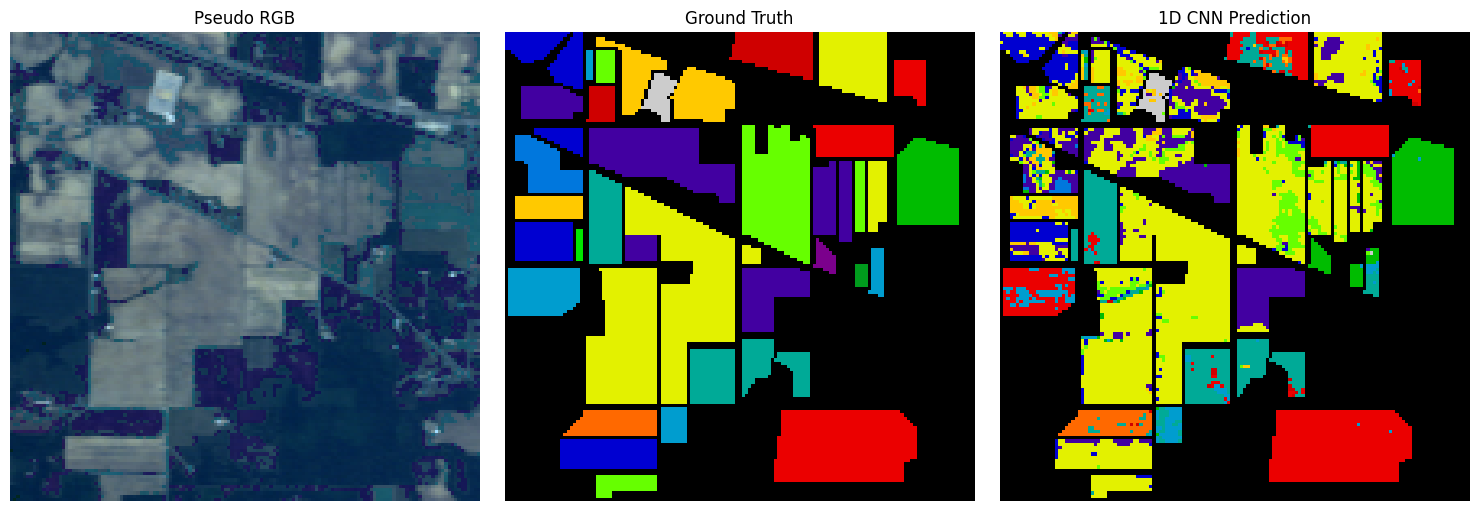

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(rgb)
axes[0].set_title('Pseudo RGB')
axes[0].axis('off')

axes[1].imshow(gt, cmap='nipy_spectral', vmin=0, vmax=len(class_names))
axes[1].set_title('Ground Truth')
axes[1].axis('off')

axes[2].imshow(pred_map, cmap='nipy_spectral', vmin=0, vmax=len(class_names))
axes[2].set_title('1D CNN Prediction')
axes[2].axis('off')

plt.tight_layout()
plt.show()



## 10. 保存结果到 `results/`

为了让这个教学 notebook 也能沉淀实验结果，这里把指标、训练曲线和预测图保存到本地结果目录。


In [18]:
output_dir = Path('results/1dcnn/IP_notebook')
output_dir.mkdir(parents=True, exist_ok=True)

metrics = {
    'seed': SEED,
    'train_ratio': TRAIN_RATIO,
    'val_ratio': VAL_RATIO,
    'test_ratio': TEST_RATIO,
    'epochs': EPOCHS,
    'batch_size': BATCH_SIZE,
    'oa': float(oa),
    'aa': float(aa),
    'kappa': float(kappa),
    'best_val_acc': float(best_val_acc),
}

(output_dir / 'metrics.json').write_text(json.dumps(metrics, indent=2), encoding='utf-8')
(output_dir / 'classification_report.txt').write_text(report, encoding='utf-8')
split_summary.to_csv(output_dir / 'split_summary.csv', index=False)
class_count_df.to_csv(output_dir / 'class_distribution.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(np.arange(1, EPOCHS + 1), history['train_loss'], marker='o')
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[1].plot(np.arange(1, EPOCHS + 1), history['train_acc'], marker='o', label='train_acc')
axes[1].plot(np.arange(1, EPOCHS + 1), history['val_acc'], marker='s', label='val_acc')
axes[1].set_title('Accuracy Curves')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
plt.tight_layout()
fig.savefig(output_dir / 'training_curves.png', dpi=200)
plt.close(fig)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(gt, cmap='nipy_spectral', vmin=0, vmax=len(class_names))
axes[0].set_title('Ground Truth')
axes[0].axis('off')
axes[1].imshow(pred_map, cmap='nipy_spectral', vmin=0, vmax=len(class_names))
axes[1].set_title('1D CNN Prediction')
axes[1].axis('off')
plt.tight_layout()
fig.savefig(output_dir / 'prediction_map.png', dpi=200)
plt.close(fig)

print('saved to', output_dir)
print(sorted(p.name for p in output_dir.iterdir()))


saved to results\1dcnn\IP_notebook
['class_distribution.csv', 'classification_report.txt', 'metrics.json', 'prediction_map.png', 'split_summary.csv', 'training_curves.png']


## 11. 小结

这份 Notebook 展示了一个完整的 1D CNN 高光谱分类流程：

- 从 `Indian Pines` 数据读取开始
- 完成像素级样本构造和标准化
- 使用 1D 卷积网络进行训练
- 在测试集上计算 OA、AA、Kappa 和分类报告
- 生成整图预测结果并保存到 `results/`

从教学角度看，1D CNN 的优势在于结构更轻，重点集中在光谱维度建模，适合作为高光谱深度学习入门示例。
